In [1]:
import seaborn as sns
from sklearn.datasets import make_blobs


In [2]:
X,y=make_blobs(
    n_samples=500,
    n_features=2,
    centers=4,
    random_state=42
    
)


<Axes: >

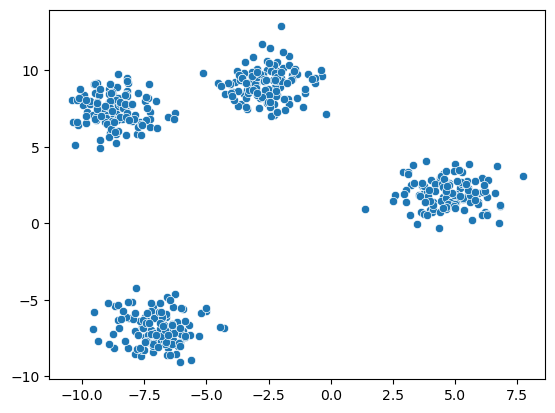

In [3]:
#visualizee 
sns.scatterplot(x=X[:,0],y=X[:,1])

In [4]:
#K-Means Clustering 
from sklearn.cluster import KMeans

In [5]:
K=4

kmeans=KMeans(
    n_clusters=K,
    random_state=42
)

In [6]:
labels=kmeans.fit_predict(X)

c:\Users\korat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


<Axes: >

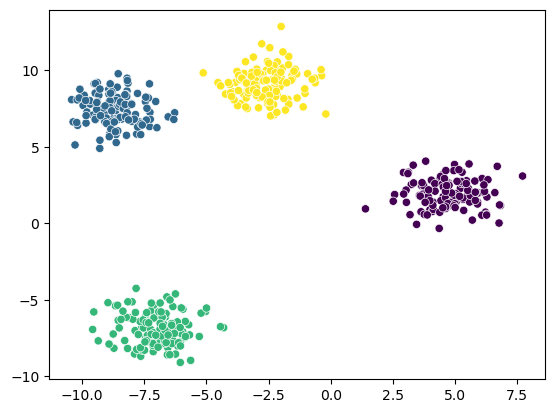

In [7]:
sns.scatterplot(x=X[:,0],y=X[:,1],c=labels)

Choose our K-value - elbow; silhouette score

In [8]:
# Elbow Method

wcss = []
for k in range(1, 21):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)

c:\Users\korat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\korat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\korat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\korat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

<Axes: >

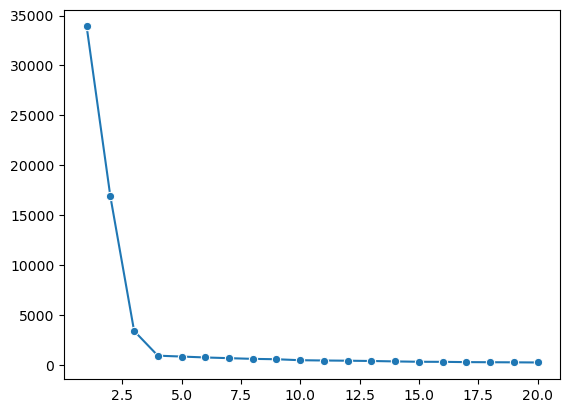

In [9]:
sns.lineplot(x=range(1, 21), y=wcss, marker="o")

In [10]:
#Kneed Model
!Pip install kneed

In [11]:
from kneed import KneeLocator

In [14]:
knee = KneeLocator(range(1, 21), wcss, curve="convex", direction="decreasing")

In [15]:
print("optimal K=",knee.elbow)

optimal K= 4


###Silhouette Score

In [19]:
from sklearn.metrics import silhouette_score

In [20]:
ss = []

for k in range(2, 21):
    kmeans = KMeans(n_clusters=k)
    labels=kmeans.fit_predict(X)
    score=silhouette_score(X,labels)

    ss.append(score)

c:\Users\korat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\korat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\korat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\korat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

<Axes: >

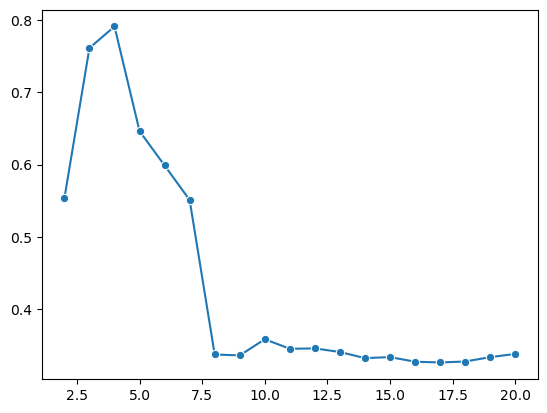

In [21]:
#plot- K & ss

sns.lineplot(x=range(2,21),y=ss,marker="o")